In [1]:
import pandas as pd   # for loading and working with tabular data
import numpy as np    # for numerical operations
import matplotlib.pyplot as plt  # for plotting graphs

# split data into training and validation sets
from sklearn.model_selection import train_test_split

# evaluation metrics
from sklearn.metrics import (
    classification_report,      # precision, recall, f1-score
    confusion_matrix,           # confusion matrix counts
    roc_auc_score,              # ROC AUC metric
    average_precision_score,    # PR AUC metric
    precision_recall_curve,     # values for PR curve
    roc_curve                   # values for ROC curve
)

# encoder for turning text categories into numbers
from sklearn.preprocessing import OrdinalEncoder

# for filling missing values
from sklearn.impute import SimpleImputer

# XGBoost classifier
from xgboost import XGBClassifier

In [2]:
# Load the training transaction data
train_trans = pd.read_csv("../data/raw/train_transaction.csv")

# Load the training identity data
train_id = pd.read_csv("../data/raw/train_identity.csv")

# Merge both tables on TransactionID
# Keep every transaction row, even if identity data is missing
df = train_trans.merge(train_id, on="TransactionID", how="left")

# Show shape and first few rows
print(df.shape)
df.head()

(590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [3]:
# Target column: what we want to predict
y = df["isFraud"]

# Drop target and ID column from features
drop_cols = ["isFraud", "TransactionID"]

# X contains the feature columns
X = df.drop(columns=drop_cols)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (590540, 432)
y shape: (590540,)


In [4]:
# Compute fraction of missing values per column
missing_pct = X.isnull().mean()

# Find columns with more than 90% missing values
high_missing_cols = missing_pct[missing_pct > 0.90].index.tolist()

# Print how many will be removed
print("Dropping", len(high_missing_cols), "columns with >90% missing values")

# Drop them
X = X.drop(columns=high_missing_cols)

# Check new shape
print("New X shape:", X.shape)

Dropping 12 columns with >90% missing values
New X shape: (590540, 420)


In [5]:
# Numeric columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

# Text/categorical columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Print counts
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 391
Categorical features: 29


C:\Users\hariv\AppData\Local\Temp\ipykernel_32540\2430111884.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [6]:
# Split into training and validation sets
# stratify=y keeps fraud percentage similar in both sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print shapes and fraud rates
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Fraud rate train:", y_train.mean())
print("Fraud rate val:", y_val.mean())

X_train: (472432, 420)
X_val: (118108, 420)
Fraud rate train: 0.03498916246147594
Fraud rate val: 0.0349933958749619


In [7]:
# Create a median imputer for numeric columns
num_imputer = SimpleImputer(strategy="median")

# Fit on training numeric columns and transform both train and validation
X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[numeric_features]),
    columns=numeric_features,
    index=X_train.index
)

X_val_num = pd.DataFrame(
    num_imputer.transform(X_val[numeric_features]),
    columns=numeric_features,
    index=X_val.index
)

# Print shapes to verify
print("X_train_num shape:", X_train_num.shape)
print("X_val_num shape:", X_val_num.shape)

X_train_num shape: (472432, 391)
X_val_num shape: (118108, 391)


In [8]:
# Fill missing categorical values with a placeholder string
cat_imputer = SimpleImputer(strategy="constant", fill_value="MISSING")

# Fit on training categorical columns and transform both train and validation
X_train_cat_filled = pd.DataFrame(
    cat_imputer.fit_transform(X_train[categorical_features]),
    columns=categorical_features,
    index=X_train.index
)

X_val_cat_filled = pd.DataFrame(
    cat_imputer.transform(X_val[categorical_features]),
    columns=categorical_features,
    index=X_val.index
)

# Ordinal-encode categories into integers
# unknown_value=-1 means unseen categories in validation become -1
cat_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train_cat = pd.DataFrame(
    cat_encoder.fit_transform(X_train_cat_filled),
    columns=categorical_features,
    index=X_train.index
)

X_val_cat = pd.DataFrame(
    cat_encoder.transform(X_val_cat_filled),
    columns=categorical_features,
    index=X_val.index
)

# Print shapes
print("X_train_cat shape:", X_train_cat.shape)
print("X_val_cat shape:", X_val_cat.shape)

X_train_cat shape: (472432, 29)
X_val_cat shape: (118108, 29)


In [9]:
# Combine processed numeric and processed categorical columns side by side
X_train_processed = pd.concat([X_train_num, X_train_cat], axis=1)
X_val_processed = pd.concat([X_val_num, X_val_cat], axis=1)

# Print shapes
print("X_train_processed:", X_train_processed.shape)
print("X_val_processed:", X_val_processed.shape)

X_train_processed: (472432, 420)
X_val_processed: (118108, 420)


In [10]:
# Count number of non-fraud and fraud examples in the training set
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

# scale_pos_weight helps XGBoost handle imbalanced classes
# It is roughly: number of negatives / number of positives
scale_pos_weight = neg_count / pos_count

print("Negative count:", neg_count)
print("Positive count:", pos_count)
print("scale_pos_weight:", scale_pos_weight)

Negative count: 455902
Positive count: 16530
scale_pos_weight: 27.580278281911674


In [11]:
# Create the XGBoost classifier
# These are solid starting parameters for a first strong model
xgb_model = XGBClassifier(
    n_estimators=300,             # number of trees
    max_depth=6,                  # tree depth
    learning_rate=0.1,            # step size
    subsample=0.8,                # use 80% of rows per tree
    colsample_bytree=0.8,         # use 80% of columns per tree
    objective="binary:logistic",  # binary classification with probability output
    eval_metric="logloss",        # evaluation metric during training
    random_state=42,              # reproducibility
    scale_pos_weight=scale_pos_weight,  # handle class imbalance
    n_jobs=-1                     # use all CPU cores
)

In [12]:
# Fit the XGBoost model on the processed training data
xgb_model.fit(X_train_processed, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [13]:
# Predict fraud class labels
y_pred_xgb = xgb_model.predict(X_val_processed)

# Predict fraud probabilities
y_proba_xgb = xgb_model.predict_proba(X_val_processed)[:, 1]

In [14]:
# Print classification report
print("XGBoost Classification Report:")
print(classification_report(y_val, y_pred_xgb))

# Print key metrics
print("XGBoost ROC AUC:", roc_auc_score(y_val, y_proba_xgb))
print("XGBoost PR AUC:", average_precision_score(y_val, y_proba_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96    113975
           1       0.31      0.83      0.45      4133

    accuracy                           0.93    118108
   macro avg       0.65      0.88      0.71    118108
weighted avg       0.97      0.93      0.94    118108

XGBoost ROC AUC: 0.951256927812655
XGBoost PR AUC: 0.7136379852421926


In [15]:
# Compute confusion matrix
cm_xgb = confusion_matrix(y_val, y_pred_xgb)

print("XGBoost Confusion Matrix:")
print(cm_xgb)

XGBoost Confusion Matrix:
[[106247   7728]
 [   704   3429]]


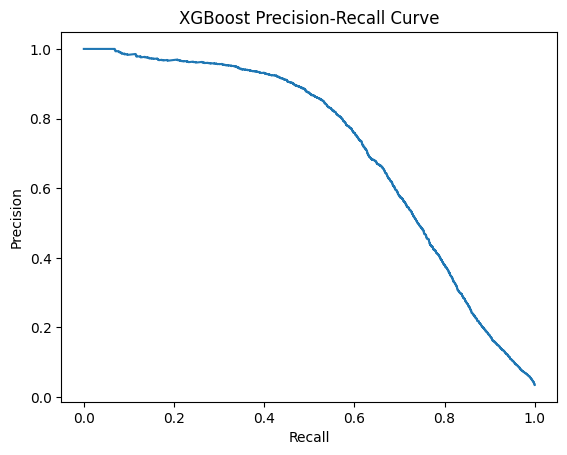

In [16]:
# Compute PR curve values
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_val, y_proba_xgb)

# Plot PR curve
plt.plot(recall_xgb, precision_xgb)

# Labels and title
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve")

# Show plot
plt.show()

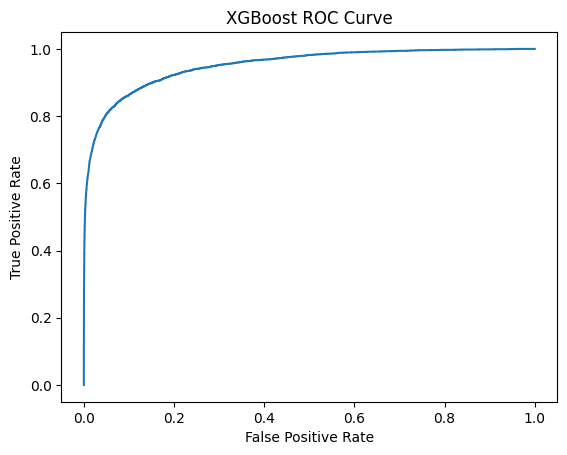

In [17]:
# Compute ROC curve values
fpr_xgb, tpr_xgb, roc_thresholds_xgb = roc_curve(y_val, y_proba_xgb)

# Plot ROC curve
plt.plot(fpr_xgb, tpr_xgb)

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")

# Show plot
plt.show()

In [18]:
# Get feature importance scores from the trained XGBoost model
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train_processed.columns
).sort_values(ascending=False)

# Show top 20 most important features
print(feature_importance.head(20))

V258     0.148575
V70      0.068005
V201     0.066318
V91      0.054098
V294     0.027173
V308     0.014216
C8       0.012503
V283     0.011243
V29      0.010479
V48      0.009718
V312     0.009439
id_34    0.009341
card6    0.009193
C14      0.008725
V49      0.007822
V50      0.007715
V69      0.007494
V187     0.007363
V102     0.007194
V128     0.006487
dtype: float32


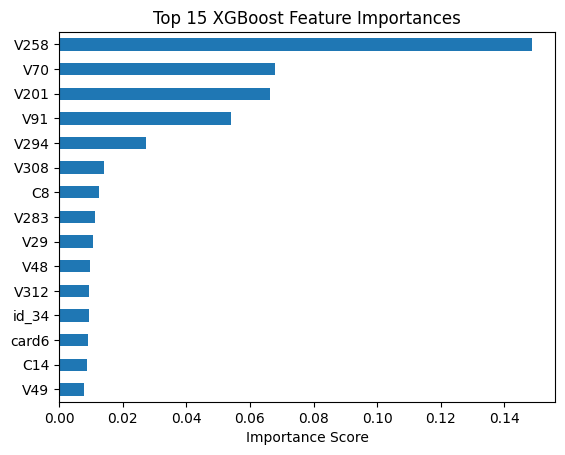

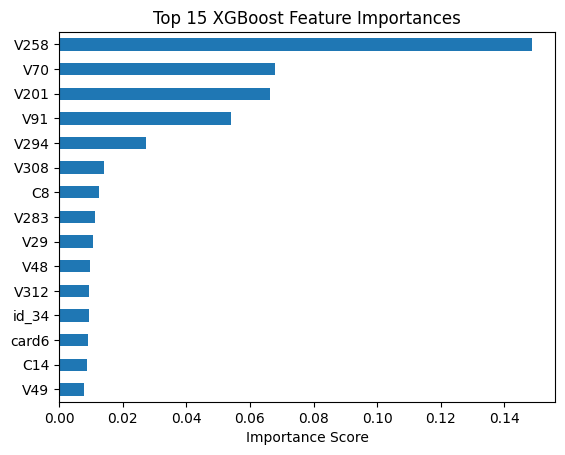

In [19]:
# Plot the top 15 most important features
feature_importance.head(15).sort_values().plot(kind="barh")

# Add labels and title
plt.xlabel("Importance Score")
plt.title("Top 15 XGBoost Feature Importances")

# Show plot
plt.show()# Plot the top 15 most important features
feature_importance.head(15).sort_values().plot(kind="barh")

# Add labels and title
plt.xlabel("Importance Score")
plt.title("Top 15 XGBoost Feature Importances")

# Show plot
plt.show()

In [20]:
# Count predicted frauds and actual frauds
print("Predicted frauds by XGBoost:", y_pred_xgb.sum())
print("Actual frauds in validation:", y_val.sum())

# Average predicted fraud probability
print("Average predicted fraud probability:", y_proba_xgb.mean())

Predicted frauds by XGBoost: 11157
Actual frauds in validation: 4133
Average predicted fraud probability: 0.19056074


## XGBoost Model Notes

- Built a stronger fraud classifier using XGBoost on the merged transaction and identity dataset.
- Dropped features with more than 90% missing values before modeling.
- Imputed numeric features with the median and categorical features with a placeholder category.
- Ordinal-encoded categorical variables so XGBoost could use them.
- Used `scale_pos_weight` to account for the severe class imbalance between fraud and non-fraud transactions.
- Evaluated the model using precision, recall, F1-score, ROC AUC, and PR AUC.
- Compared results against the logistic regression baseline and observed a major improvement in fraud precision, recall, and PR AUC.
- Inspected feature importances to identify which variables contributed most to fraud prediction.